# RelayBP Hyperparameter Tuning

This notebook is a refactor of https://github.com/trmue/relay/blob/main/examples/RotatedSurfaceCodeAnalysis.ipynb.

Three-phase workflow for tuning the RelayBP decoder on rotated surface codes with phenomenological noise:
1. **Phase 1** — Sweep `gamma0` to find the optimal base memory strength
2. **Phase 2** — Optimize `gamma_dist_interval` using Nevergrad
3. **Phase 3** — Compare RelayBP vs BP vs MWPM across error rates

In [1]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import sinter
import matplotlib.pyplot as plt
import os

from qecdec.experiments import RotatedSurfaceCode_Memory
from qecdec.decoders import RelayBPDecoder, BPDecoder
from qecdec.sinter_utils import QecdecSinterDecoder

## Phase 1 — gamma0 sweep

In [12]:
d_list = [5, 7, 9]  # list of code distances
basis = "Z"  # measurement basis
p = 0.01  # physical error rate
num_relays = 16
pre_iter = 50
max_iter_per_relay = 50
stop_nconv = 1

# List of gamma0 values to sweep
gamma0_list = np.linspace(0, 1, 21).tolist()

# Default gamma_dist_interval value (gamma_dist_interval will be tuned in Phase 2)
default_gamma_dist_interval = (-0.25, 1.0)

In [13]:
def generate_gamma0_sweep_tasks():
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}
    for d in d_list:
        expmt = RotatedSurfaceCode_Memory(
            d=d,
            rounds=d,
            basis=basis,
            data_qubit_error_rate=p,
            meas_error_rate=p,
        )
        for gamma0 in gamma0_list:
            decoder = RelayBPDecoder(
                expmt.chkmat,
                expmt.prior,
                gamma0=gamma0,
                gamma_dist_interval=default_gamma_dist_interval,
                num_relays=num_relays,
                pre_iter=pre_iter,
                max_iter_per_relay=max_iter_per_relay,
                stop_nconv=stop_nconv,
            )
            custom_decoder_id = f"custom_decoder_{len(custom_decoders)}"
            custom_decoders[custom_decoder_id] = QecdecSinterDecoder(
                decoder, expmt.obsmat
            )
            tasks.append(
                sinter.Task(
                    circuit=expmt.circuit,
                    detector_error_model=expmt.dem,
                    decoder=custom_decoder_id,
                    json_metadata={"d": d, "gamma0": gamma0},
                )
            )
    return tasks, custom_decoders


tasks, custom_decoders = generate_gamma0_sweep_tasks()

In [ ]:
gamma0_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=tasks,
    custom_decoders=custom_decoders,
    # print_progress=True,
)

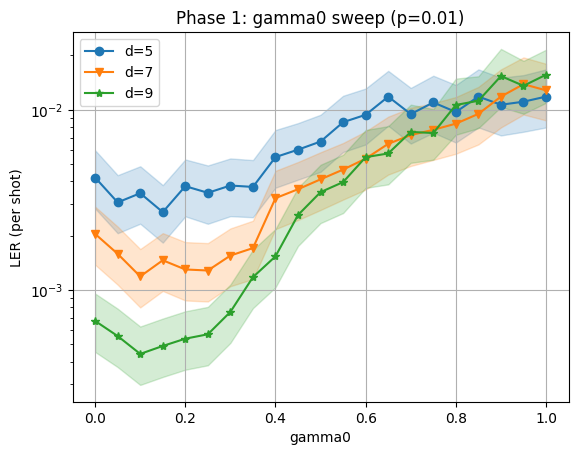

In [15]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=gamma0_stats,
    group_func=lambda stat: f"d={stat.json_metadata['d']}",
    x_func=lambda stat: stat.json_metadata["gamma0"],
)
ax.semilogy()
ax.grid()
ax.set_ylabel("LER (per shot)")
ax.set_xlabel("gamma0")
ax.set_title(f"Phase 1: gamma0 sweep (p={p})")
ax.legend()

In [16]:
# Pick the best gamma0 (manually from the plot above)
gamma0_star = 0.1  # <-- UPDATE THIS after inspecting the plot

## Phase 2 — Nevergrad optimization of gamma_dist_interval

In [17]:
import nevergrad as ng

In [28]:
# Target distance for optimization (use smallest for speed)
opt_d = 5
opt_expmt = RotatedSurfaceCode_Memory(
    d=opt_d,
    rounds=opt_d,
    basis=basis,
    data_qubit_error_rate=p,
    meas_error_rate=p,
)


def objective(low: float, high: float) -> float:
    """Return the logical error rate for a given gamma_dist_interval."""
    if low >= high:
        return 1.0  # invalid interval

    decoder = RelayBPDecoder(
        opt_expmt.chkmat,
        opt_expmt.prior,
        gamma0=gamma0_star,
        gamma_dist_interval=(low, high),
        num_relays=num_relays,
        pre_iter=pre_iter,
        max_iter_per_relay=max_iter_per_relay,
        stop_nconv=stop_nconv,
    )
    custom_decoders = {"opt_decoder": QecdecSinterDecoder(decoder, opt_expmt.obsmat)}
    tasks = [
        sinter.Task(
            circuit=opt_expmt.circuit,
            detector_error_model=opt_expmt.dem,
            decoder="opt_decoder",
            # json_metadata={},
        )
    ]
    stats = sinter.collect(
        num_workers=os.cpu_count() - 1,
        max_shots=1_000_000,
        max_errors=100,
        tasks=tasks,
        custom_decoders=custom_decoders,
    )
    return stats[0].errors / stats[0].shots

In [ ]:
relay_params = ng.p.Instrumentation(
    low=ng.p.Scalar(init=default_gamma_dist_interval[0], lower=-0.5, upper=0.5),
    high=ng.p.Scalar(init=default_gamma_dist_interval[1], lower=0.0, upper=1.0),
)


def ensure_gamma_interval_ordered(vals):
    param_dict = vals[1]
    return param_dict["low"] < param_dict["high"]


relay_params.register_cheap_constraint(ensure_gamma_interval_ordered)

optimizer = ng.optimizers.TwoPointsDE(parametrization=relay_params, budget=100)
optimizer.register_callback("tell", ng.callbacks.ProgressBar())

recommendation = optimizer.minimize(objective, verbosity=1)
opt_low = recommendation[1]["low"].value
opt_high = recommendation[1]["high"].value
print(f"Optimal gamma_dist_interval: ({opt_low:.4f}, {opt_high:.4f})")

In [31]:
gamma_dist_interval_star = (opt_low, opt_high)
print(f"gamma0_star = {gamma0_star}")
print(f"gamma_dist_interval_star = {gamma_dist_interval_star}")

gamma0_star = 0.1
gamma_dist_interval_star = (-0.16899095501924102, 0.4034331405765614)


## Phase 3 — Error rate sweep: RelayBP vs BP vs MWPM

In [32]:
p_list = [0.004, 0.006, 0.008, 0.01, 0.012]
bp_max_iter = 50


def generate_comparison_tasks():
    tasks: list[sinter.Task] = []
    custom_decoders: dict[str, sinter.Decoder] = {}
    for p_val in p_list:
        expmt = RotatedSurfaceCode_Memory(
            d=opt_d,
            rounds=opt_d,
            basis=basis,
            data_qubit_error_rate=p_val,
            meas_error_rate=p_val,
        )

        # MWPM (pymatching)
        tasks.append(
            sinter.Task(
                circuit=expmt.circuit,
                detector_error_model=expmt.dem,
                decoder="pymatching",
                json_metadata={"p": p_val, "decoder": "MWPM"},
            )
        )

        # BP
        bp = BPDecoder(expmt.chkmat, expmt.prior, max_iter=bp_max_iter)
        bp_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[bp_id] = QecdecSinterDecoder(bp, expmt.obsmat)
        tasks.append(
            sinter.Task(
                circuit=expmt.circuit,
                detector_error_model=expmt.dem,
                decoder=bp_id,
                json_metadata={"p": p_val, "decoder": "BP"},
            )
        )

        # RelayBP (with tuned params)
        relay = RelayBPDecoder(
            expmt.chkmat,
            expmt.prior,
            gamma0=gamma0_star,
            gamma_dist_interval=gamma_dist_interval_star,
            num_relays=num_relays,
            pre_iter=pre_iter,
            max_iter_per_relay=max_iter_per_relay,
            stop_nconv=stop_nconv,
        )
        relay_id = f"custom_decoder_{len(custom_decoders)}"
        custom_decoders[relay_id] = QecdecSinterDecoder(relay, expmt.obsmat)
        tasks.append(
            sinter.Task(
                circuit=expmt.circuit,
                detector_error_model=expmt.dem,
                decoder=relay_id,
                json_metadata={"p": p_val, "decoder": "RelayBP"},
            )
        )
    return tasks, custom_decoders


cmp_tasks, cmp_custom_decoders = generate_comparison_tasks()

In [ ]:
cmp_stats = sinter.collect(
    num_workers=os.cpu_count() - 1,
    max_shots=10_000_000,
    max_errors=100,
    tasks=cmp_tasks,
    custom_decoders=cmp_custom_decoders,
    # print_progress=True,
)

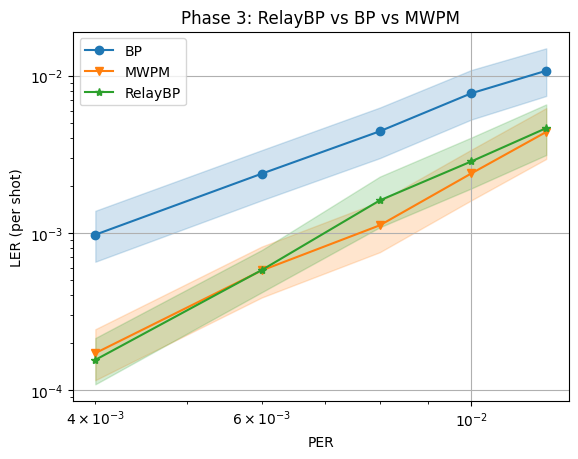

In [34]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=cmp_stats,
    group_func=lambda stat: f"{stat.json_metadata['decoder']}",
    x_func=lambda stat: stat.json_metadata["p"],
)
ax.loglog()
ax.grid()
ax.set_ylabel("LER (per shot)")
ax.set_xlabel("PER")
ax.set_title("Phase 3: RelayBP vs BP vs MWPM")
ax.legend()